# 06 — Anomaly Detection

## 1. Objective

## 2. Load Dataset

## 3. Train/Test Split

## 4. Prepare Normal Transactions

## 5. Isolation Forest

## 6. Isolation Forest Evaluation

## 7. Autoencoder

## 8. Reconstruction Error

## 9. Autoencoder Evaluation

## 10. Compare Anomaly Detectors

## 11. Anomaly Score Analysis

## 12. Conclusions

In [57]:
%pip install --upgrade tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
DATA_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

Shape: (284807, 31)


In [59]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [60]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [62]:
normal_mask = y_train == 0

X_train_normal = X_train_scaled[normal_mask]

print("Normal training samples:", X_train_normal.shape)

Normal training samples: (199020, 30)


In [63]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_train_normal)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [64]:
test_anomaly_score = -isolation_forest.score_samples(
    X_test_scaled
)

In [65]:
print(
    pd.Series(test_anomaly_score).describe()
)

count    42722.000000
mean         0.408774
std          0.041976
min          0.351326
25%          0.380364
50%          0.399367
75%          0.424531
max          0.726747
dtype: float64


In [66]:
if_roc_auc = roc_auc_score(
    y_test,
    test_anomaly_score
)

print("Isolation Forest ROC-AUC:", if_roc_auc)

Isolation Forest ROC-AUC: 0.9462843541346637


In [67]:
if_pr_auc = average_precision_score(
    y_test,
    test_anomaly_score
)

print("Isolation Forest PR-AUC:", if_pr_auc)

Isolation Forest PR-AUC: 0.13054665137839175


In [68]:
print(
    test_anomaly_score.min(),
    test_anomaly_score.max()
)

percentiles = [90, 95, 97, 98, 99, 99.5]
threshold_results = []

for p in percentiles:

    threshold = np.percentile(
        test_anomaly_score,
        p
    )

    predictions = (
        test_anomaly_score >= threshold
    ).astype(int)

    threshold_results.append({
        "Percentile": p,
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

if_threshold_df = pd.DataFrame(
    threshold_results
)

if_threshold_df

0.35132627032999314 0.726747408130921


,Percentile,Threshold,Precision,Recall,F1
0,90.0,0.456138,0.015446,0.891892,0.030366
1,95.0,0.485464,0.029481,0.851351,0.056988
2,97.0,0.512942,0.044462,0.770270,0.084071
3,98.0,0.537528,0.057310,0.662162,0.105490
4,99.0,0.576867,0.100467,0.581081,0.171315
5,99.5,0.609221,0.140187,0.405405,0.208333


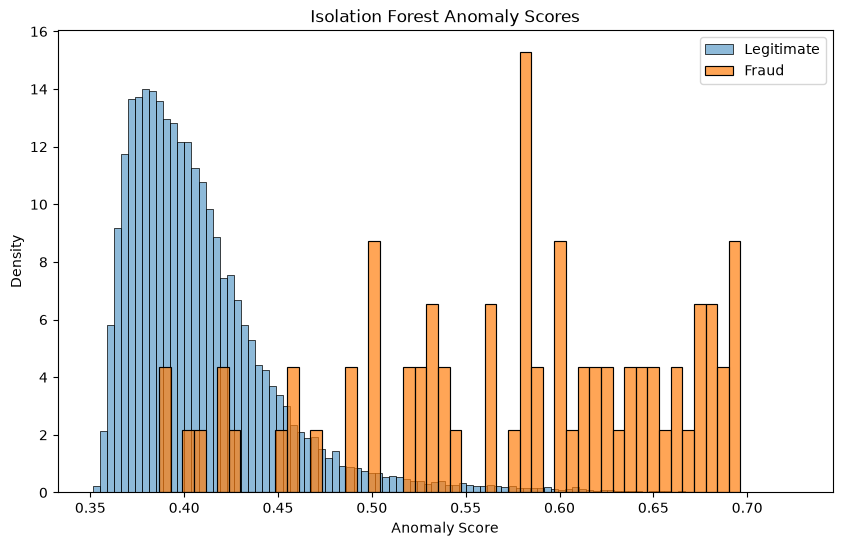

In [69]:
plt.figure(figsize=(10, 6))

sns.histplot(
    test_anomaly_score[y_test.values == 0],
    bins=100,
    stat="density",
    alpha=0.5,
    label="Legitimate"
)

sns.histplot(
    test_anomaly_score[y_test.values == 1],
    bins=50,
    stat="density",
    alpha=0.7,
    label="Fraud"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.title("Isolation Forest Anomaly Scores")

plt.legend()
plt.show()

In [70]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense
)

In [71]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\nikhi\AppData\Local\Programs\Python\Python312\python.exe

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [72]:
import sys

!{sys.executable} -m pip --version

pip 25.0.1 from c:\Users\nikhi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)



In [73]:
import sys

!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [75]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

print("Keras is working!")

Keras is working!


In [76]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train shape: (199364, 30)
X_test shape: (42722, 30)
X_train_scaled shape: (199364, 30)
X_test_scaled shape: (42722, 30)


In [77]:
normal_mask = y_train == 0

X_train_normal = X_train_scaled[normal_mask]

print("Normal transactions:", X_train_normal.shape)

Normal transactions: (199020, 30)


In [78]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train_normal.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(
    16,
    activation="relu"
)(input_layer)

encoded = Dense(
    8,
    activation="relu"
)(encoded)

encoded = Dense(
    4,
    activation="relu"
)(encoded)

decoded = Dense(
    8,
    activation="relu"
)(encoded)

decoded = Dense(
    16,
    activation="relu"
)(decoded)

decoded = Dense(
    input_dim,
    activation="linear"
)(decoded)

autoencoder = Model(
    input_layer,
    decoded
)

In [79]:
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362 (5.32 KB)

 Trainable params: 1,362 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

In [81]:
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=30,
    batch_size=256,
    validation_split=0.10,
    shuffle=True,
    verbose=1
)
X_train_normal,
X_train_normal

Epoch 1/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.8678 - val_loss: 0.7823
Epoch 2/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7663 - val_loss: 0.7298
Epoch 3/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7267 - val_loss: 0.7058
Epoch 4/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7003 - val_loss: 0.6806
Epoch 5/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6754 - val_loss: 0.6636
Epoch 6/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6596 - val_loss: 0.6491
Epoch 7/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6450 - val_loss: 0.6382
Epoch 8/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6331 - val_loss: 0.6285
Epoch 9/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6212 - val_loss: 0.6168
Epoch 10/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6121 - val_loss: 0.6162
Epoch 11/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6079 - val_loss: 0.6067
Epoch 12/30
700/700 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

array([[ 1.25799168, -0.00557826,  0.4278193 , ...,  0.57962275,
         0.25246159, -0.3210821 ],
       [ 0.93971289,  0.90410915, -0.11013829, ..., -0.1835134 ,
        -0.17372534,  0.24347542],
       [-0.52896001, -0.55054428, -2.6769007 , ..., -0.77644611,
         0.68944825,  4.79759381],
       ...,
       [-0.71876914, -0.76142256,  0.39801874, ..., -1.09887677,
         0.13544642, -0.2030889 ],
       [-1.2549473 ,  0.54477537,  0.04470792, ...,  0.07705819,
         0.07389814, -0.16977736],
       [-1.39085013, -0.30368651,  0.46865476, ...,  0.92950974,
         0.62433914, -0.32163531]], shape=(199020, 30))

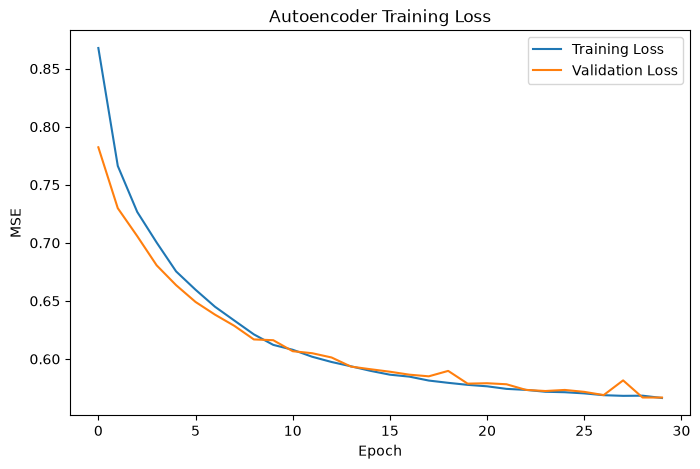

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Autoencoder Training Loss")

plt.legend()
plt.show()

In [83]:
X_test_reconstructed = autoencoder.predict(
    X_test_scaled,
    verbose=0
)
print(
    "Original shape:",
    X_test_scaled.shape
)

print(
    "Reconstructed shape:",
    X_test_reconstructed.shape
)

Original shape: (42722, 30)
Reconstructed shape: (42722, 30)


In [84]:
reconstruction_error = np.mean(
    np.square(
        X_test_scaled -
        X_test_reconstructed
    ),
    axis=1
)

In [85]:
print(
    pd.Series(reconstruction_error).describe()
)

count    42722.000000
mean         0.591719
std          1.741560
min          0.040118
25%          0.244739
50%          0.378455
75%          0.615095
max         84.226338
dtype: float64


In [86]:
normal_errors = reconstruction_error[
    y_test.values == 0
]

fraud_errors = reconstruction_error[
    y_test.values == 1
]

print("Normal mean error:", normal_errors.mean())
print("Fraud mean error:", fraud_errors.mean())

Normal mean error: 0.559425802571123
Fraud mean error: 19.202844141511303


In [87]:
from sklearn.metrics import roc_auc_score

ae_roc_auc = roc_auc_score(
    y_test,
    reconstruction_error
)

print(
    "Autoencoder ROC-AUC:",
    ae_roc_auc
)

Autoencoder ROC-AUC: 0.9535918163520866


In [88]:
from sklearn.metrics import average_precision_score

ae_pr_auc = average_precision_score(
    y_test,
    reconstruction_error
)

print(
    "Autoencoder PR-AUC:",
    ae_pr_auc
)

Autoencoder PR-AUC: 0.3180559251763162


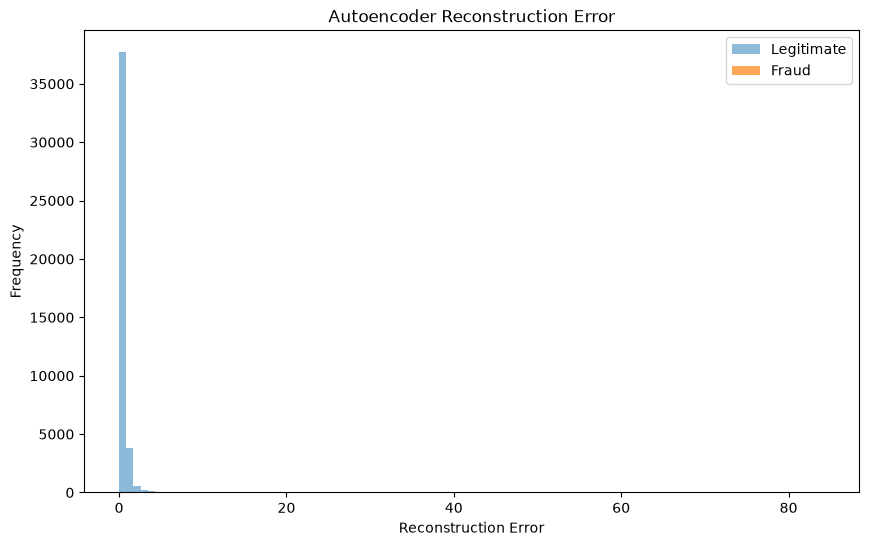

In [89]:
plt.figure(figsize=(10, 6))

plt.hist(
    normal_errors,
    bins=100,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    fraud_errors,
    bins=50,
    alpha=0.7,
    label="Fraud"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Autoencoder Reconstruction Error")

plt.legend()
plt.show()

In [90]:
percentiles = [
    90,
    95,
    97,
    98,
    99,
    99.5
]
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

ae_threshold_results = []

for percentile in percentiles:

    threshold = np.percentile(
        reconstruction_error,
        percentile
    )

    predictions = (
        reconstruction_error >= threshold
    ).astype(int)

    ae_threshold_results.append({
        "Percentile": percentile,
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

ae_threshold_df = pd.DataFrame(
    ae_threshold_results
)

ae_threshold_df

,Percentile,Threshold,Precision,Recall,F1
0,90.0,0.946138,0.015212,0.878378,0.029906
1,95.0,1.322685,0.029481,0.851351,0.056988
2,97.0,1.676034,0.048362,0.837838,0.091445
3,98.0,2.082181,0.072515,0.837838,0.133477
4,99.0,3.354578,0.137850,0.797297,0.235060
5,99.5,6.127124,0.200935,0.581081,0.298611


In [91]:
anomaly_comparison = pd.DataFrame([
    {
        "Model": "Isolation Forest",
        "ROC-AUC": if_roc_auc,
        "PR-AUC": if_pr_auc
    },
    {
        "Model": "Autoencoder",
        "ROC-AUC": ae_roc_auc,
        "PR-AUC": ae_pr_auc
    }
])

anomaly_comparison

,Model,ROC-AUC,PR-AUC
0,Isolation Forest,0.946284,0.130547
1,Autoencoder,0.953592,0.318056
